# Module 6 - Programming Assignment

## Directions

1. Change the name of this file to be your JHED id as in `jsmith299.ipynb`. Because sure you use your JHED ID (it's made out of your name and not your student id which is just letters and numbers).
2. Make sure the notebook you submit is cleanly and fully executed. I do not grade unexecuted notebooks.
3. Submit your notebook back in Blackboard where you downloaded this file.

*Provide the output **exactly** as requested*

In [1]:
%matplotlib inline

import matplotlib.pyplot as plt
import networkx as nx
from copy import deepcopy
from operator import itemgetter

**For this assignment only**

If you want to use NetworkX with your assignment, you can do:

```
conda install networkx
```
or

```
pip install networkx
```

Additionally, this assignment uses a recursive algorithm. You should use `deecopy` at the appropriate places to avoid entanglement issues.

1. Follow the pseudocode in the book exactly.
2. Learn about the [Four Color Theorem](http://en.wikipedia.org/wiki/Four_color_theorem).


These links are to help me navigate your notebook:

1. [Four Color Connecticut](#four_ct)
2. [Three Color Connecticut](#three_ct)
3. [Four Color Europe](#four_eu)
4. [Three Color Europe](#three_eu)


## CSP: Map Coloring

In this programming assignment, you will be using your new understanding of **Constraint Satisfaction Problems** to color maps. As we know from the [Four Color Theorem](http://en.wikipedia.org/wiki/Four_color_theorem) any division of a plane into contiguous regions can be colored such that no two adjacent regions are the same color by using at most four colors.

From the book, we know that we can translate this problem into a CSP where the map is represented as a [planar graph](http://en.wikipedia.org/wiki/Planar_graph) and the goal is to color all the nodes such that no adjacent nodes are colored the same color.

As with most AI problems, this requires us to figure out how best to represent the problem--and the solution--given the high and low level data structures and types at our disposal. For this problem, we'll settle on a Dict which contains at least two keys: "nodes" which is an *ordered* List of Strings that represents each node or vertex in the planar graph and "edges" which contains a List of Tuples that represent edges between nodes. The Tuples are of ints that represent the index of the node in the "nodes" list.

Using this system, and adding a "coordinates" key with abstract drawing coordinates of each node for NetworkX, we can represent the counties of Connecticut like so:

In [2]:
connecticut = {
    'coordinates': [(46, 52), (217, 146), (65, 142), (147, 85), (162, 140),
                 (104, 77), (197, 94), (123, 142)],
    'edges': [(0, 2), (0, 5), (2, 5), (2, 7), (5, 7), (5, 3), (7, 3), (7, 4),
           (7, 6), (3, 6), (4, 6), (4, 1), (6, 1)],
    'nodes': ['Fairfield', 'Windham', 'Litchfield', 'Middlesex', 'Tolland',
           'New Haven', 'New London', 'Hartford']}
print(connecticut)

{'coordinates': [(46, 52), (217, 146), (65, 142), (147, 85), (162, 140), (104, 77), (197, 94), (123, 142)], 'edges': [(0, 2), (0, 5), (2, 5), (2, 7), (5, 7), (5, 3), (7, 3), (7, 4), (7, 6), (3, 6), (4, 6), (4, 1), (6, 1)], 'nodes': ['Fairfield', 'Windham', 'Litchfield', 'Middlesex', 'Tolland', 'New Haven', 'New London', 'Hartford']}


The coordinates permit us to use NetworkX to draw the graph. We'll add a helper function for this, `draw_map`, which takes our planar_map, a figure size in abstract units, and a List of color assignments in the same order as the nodes in the planar_map.  The underlying drawings are made by matplotlib using NetworkX on top of it. Incidentally, the positions just make the map "work out" on NetworkX/matplotlib.

The size parameter is actually inches wide by inches tall (8, 10) is an 8x10 sheet of paper. Why doesn't a chart cover up the whole screen then? It's adjusted by dpi. On high resolution monitors, 300 dpi with 8x10 inches might only take up a fraction of that space. Use whatever you want to make the output look good. It doesn't matter for anything else but that.

A default value for `color_assignments` is provided, `None`, that simply colors all the nodes red. Otherwise, `color_assignments` must be a `List of Tuples` where each `Tuple` is a node name and assigned color. The order of `color_assignments` must be the same as the order of `"nodes"` in the `planar_map`.


<div style="background: lemonchiffon; margin:20px; padding: 20px;">
    <strong>Important</strong>
    <p>Do not use NetworkX nodes as the data structure for your assignment.
    We are only using it to color the maps.
    Use basic Python data structures as specified in the general programming requirements.</p>
</div>


In [3]:
def draw_map(name, planar_map, size, color_assignments=None):
    def as_dictionary(a_list):
        dct = {}
        for i, e in enumerate(a_list):
            dct[i] = e
        return dct
    
    G = nx.Graph()
    
    labels = as_dictionary(planar_map["nodes"])
    pos = as_dictionary(planar_map["coordinates"])
    
    # create a List of Nodes as indices to match the "edges" entry.
    nodes = [n for n in range(0, len(planar_map["nodes"]))]

    if color_assignments:
        colors = [c for n, c in color_assignments]
    else:
        colors = ['red' for c in range(0,len(planar_map[ "nodes"]))]

    G.add_nodes_from(nodes)
    G.add_edges_from(planar_map[ "edges"])

    plt.figure(figsize=size, dpi=100)
    plt.title(name)
    nx.draw(G, node_color = colors, with_labels = True, labels = labels, pos = pos)
    
#    plt.savefig(name + ".png")

Using this function, we can draw `connecticut`:

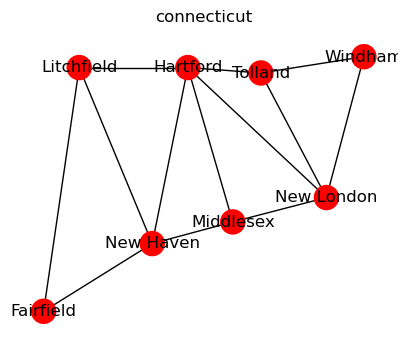

In [4]:
draw_map("connecticut", connecticut, (5,4), [(n, "red") for n in connecticut["nodes"]])

This coloring obviously has some problems! You're going to write a program to fix it.

So what we (and by "we", I mean "you") would like to do is write a program that can figure out how to color a planar map...ie, `connecticut` *and* `europe`, you will do it by implementing a function that uses the algorithms that were discussed in this module.

## Which CSP Algorithms?

You will need to implement **backtracking** and **forward checking**. Look at the pseudocode for `backtracking_search` on p. 192 of AIAMA 4th Edition.

You *must* implement **Degree Heuristic** (to pick variables) and **Least Constraining Value** (to pick values).
You *may* implement **Minimum Remaining Values** as a tie breaker, if you like.
Otherwise, break ties in ascending order (least to most).
(Which functions in the pseudocode represent the heuristics?).

You should get the backtracking and forward checking implemented first. 
Then add the heuristics. 
You must use the pseudocode in the book and then stub out the functions that implement the "pick a variable" heuristic and the "pick a value" heuristic. 
When you get it working, fill in the appropriate heuristic mentioned above.

Please change the "?" below into "yes" or "no" indicating which elements you were able to implement:

```
Required:
    backtracking: yes
    forward checking: yes
    degree heuristic: yes
    least contraining value: yes
Optional:    
    minimum remaining values: no (hard to implement when values are not numerical - did not feel necessary)
```  

Your function should take the following form:

```python
def color_map( planar_map, color_list, trace=False)
```

where `planar_map` has the format described above, colors is a List of Strings denoting the colors to use and `trace` operates as described in the next paragraph. It should return a List of Tuples where each Tuple is of the form `( Node Name, Color)` in the same order as the `node` entry in the planar_map. For example, if we had `["A", "B"]` as nodes and `["Yellow", "Green"]` as colors, your function might return `[("A", "Yellow"), ("B", "Green")]`. If a coloring cannot be found, return `None`.

Your function also will take an optional argument, `trace`, with a default value of `False`.

If `trace` is set to `True` your program will print out *traces* (or debugging) statements that show what it is currently doing (in terms of the algorithms you are supposed to implement):

1. The variable selected and why.
2. The values proposed in order.
3. backtracking detected by forward checking (empty domains).

Don't print out a lot of noise.

As usual, you should implement your function using helper functions, using one Markdown cell for documentation and one Codecell for implementation (one function and assertions).

-----

<a id="calculate_degree_heuristic"></a>
## calculate_degree_heuristic

To speed up the process of finding a solution, the CSP algorithm should identify which variables do not have an assignment and only evaluate those too prevent repetition. Often, a heuristic is used to find the optimal variable to choose. The Degree Heuristic is one such heuristic that chooses the unassigned variable with the highest degree constraints to evaluate next. This function calculates the number of unassigned neighbors each unassigned variable has. The number of unassigned neighbore for a given variable is considered the number of constraints for the variable. 

* **assignment** Dict[str: str]: dictionary holding the values of the assigned variables
* **graph** Dict[str: List]: dictionary holding information of the map: coordinates, edges and nodes
  
**returns** List(Tuple): list of the unassigned variables and its corresponding degree of constraints

In [5]:
def calculate_degree_heuristic(assignment, graph):
    unassigned_degrees = []
    
    # Only consider unassigned nodes for the degree calculation
    unassigned_nodes = [node for node in graph['nodes'] if node not in assignment]
    for node in unassigned_nodes:
        degree = 0
        for edge in graph['edges']:
            # Convert edge indices to node names
            node1, node2 = graph['nodes'][edge[0]], graph['nodes'][edge[1]]
            # Check if the edge connects to another unassigned node
            if node == node1 and node2 in unassigned_nodes:
                degree += 1
            elif node == node2 and node1 in unassigned_nodes:
                degree += 1
        unassigned_degrees.append((node, degree))
    return unassigned_degrees


In [6]:
graph = {
    'edges': [(0, 2), (0, 5), (2, 5), (2, 7), (5, 7), (5, 3), (7, 3), (7, 4),
           (7, 6), (3, 6), (4, 6), (4, 1), (6, 1)],
    'nodes': ['A', 'B', 'C', 'D', 'E',
           'F', 'G', 'H']}

assert len(calculate_degree_heuristic({}, graph)) == 8
assert calculate_degree_heuristic({}, graph)[0][1] == 2 
assert len(calculate_degree_heuristic({'A': "red", 'B': 'green'}, graph)) == 6

<a id="select_unassigned_variable"></a>
## select_unassigned_variable

To speed up the process of finding a solution, the CSP algorithm should identify which variables do not have an assignment and only evaluate those to prevent repetition. Often, a heuristic is used to find the optimal variable to choose. The Degree Heuristic is one such heuristic that chooses the unassigned variable with the highest degree constraints to evaluate next. This function returns the unassigned variable with the highest degree constraint. 

* **assignment** Dict[str: str]: dictionary holding the values of the assigned variables
* **graph** Dict[str: List]: dictionary holding information of the map: coordinates, edges and nodes
* **trace** Boolean: true/false if tracking statements should be printed
  
**returns** str: variable name with the highest degree constraint

In [7]:
def select_unassigned_variable(assignment, graph, trace):
    unassigned_degrees = calculate_degree_heuristic(assignment, graph)
    
    # Sort based on degree heuristic, descending order
    unassigned_degrees.sort(key=lambda x: x[1], reverse=True)

    if unassigned_degrees and trace:
        #print("\nUnassigned Variables to Choose From: "  +str(unassigned_degrees))
        print("Chosen Variable with Degree Heuristic: " + str(unassigned_degrees[0]))
    
    return unassigned_degrees[0][0] if unassigned_degrees else None

In [8]:
graph = {
    'edges': [(0, 2), (0, 5), (2, 5), (2, 7), (5, 7), (5, 3), (7, 3), (7, 4),
           (7, 6), (3, 6), (4, 6), (4, 1), (6, 1)],
    'nodes': ['A', 'B', 'C', 'D', 'E',
           'F', 'G', 'H']}

assert select_unassigned_variable({}, graph, False) == 'H'
assert select_unassigned_variable({'C': "red", 'D': 'green', 'F': 'blue'}, graph, False) == 'E'
assert select_unassigned_variable({'A': "red", 'B': "red", 'C': "red", 'D': 'green','E': "red", 'F': 'blue', 'G': "red", 'H': "red"}, graph, False) == None

<a id="is_value_consistent"></a>
## is_value_consistent

In Constraint Satisfaction Problems, the term 'consistent' is used to find out whether an assignment is valid. For an assignment to be valid, no constraint should be broken. In the case of the map coloring, an assignment is consistent if no neighboring region has the same value as the current region. This function checks if an assignment is consistent, or valid. 

* **variable** str: name of the variable for which the value is evaluated
* **value** str: value to be assigned to the variable
* **assignment** Dict[str: str]: dictionary holding the values of the assigned variables
* **graph** Dict[str: List]: dictionary holding information of the map: coordinates, edges and nodes
  
**returns** Boolean: True if assignment is consistent, False if not

In [9]:
def is_value_consistent(variable, value, assignment, graph):
    for edge in graph['edges']:
        # Convert edge indices to node names
        node1, node2 = graph['nodes'][edge[0]], graph['nodes'][edge[1]]
        if variable == node1 and node2 in assignment and assignment[node2] == value:
            return False
        if variable == node2 and node1 in assignment and assignment[node1] == value:
            return False
    return True

In [10]:
graph = {
    'edges': [(0, 2), (0, 5), (2, 5), (2, 7), (5, 7), (5, 3), (7, 3), (7, 4),
           (7, 6), (3, 6), (4, 6), (4, 1), (6, 1)],
    'nodes': ['A', 'B', 'C', 'D', 'E',
           'F', 'G', 'H']}

assert is_value_consistent('A', 'red', {'C': 'red'}, graph) == False
assert is_value_consistent('A', 'blue', {'C': 'red'}, graph) == True
assert is_value_consistent('C', 'red', {'A': 'red'}, graph) == False
assert is_value_consistent('A', 'red', {'C': 'blue'}, graph) == True

<a id="order_domain_values"></a>
## order_domain_values

The Least Constraining Value Heuristic identifies the value that rules out the fewest choices for the neighboring variables in the graph. This heurisitic is a method often used in Constraint Satisfaction Problems to choose the most optimal values in a given domain - potentially reducing the time taken to find a solution if one is available. 

This function returns a list of the domains of a node in order of the least constraining value to the highest constraining value. 

* **variable** str: name of the variable for which the values are evaluated
* **assignment** Dict[str: str]: dictionary holding the values of the assigned variables
* **graph** Dict[str: List]: dictionary holding information of the map: coordinates, edges and nodes
* **colors** List[str]: list of possible colors that can be used in map
* **domain** Dict[:List]: true/false if tracking statements should be printed
* **trace** Boolean: true/false if tracking statements should be printed

  
**returns** List[Tuple]: list of color assignments to each region (node, color) or None if no solution was found

In [11]:
def order_domain_values(variable, assignment, graph, colors, domain, trace):
    """Order domain values for var using Least Constraining Value heuristic."""
    if variable in assignment:
        return [assignment[variable]]

    domain_constrained = []
    for color in domain[variable]:
        #impact = sum(1 for edge in graph['edges'] if variable in edge for neighbor in edge if neighbor != variable and color in domain[graph['nodes'][neighbor]])
    
        count = 0
        for edge in graph['edges']:
            node1, node2 = graph['nodes'][edge[0]], graph['nodes'][edge[1]]
            if variable == node1 or variable == node2:
                neighbor = node2 if variable == node1 else node1
                if neighbor in assignment:
                    continue  # Skip already assigned neighbors
                if color in domain[neighbor]:
                    count += 1
        domain_constrained.append((color, count))


    domain_constrained = sorted(domain_constrained, key = itemgetter(1))
    
    if trace: 
        print("Value with Least Constraints: " + str(domain_constrained[0]))
    return [i[0] for i in domain_constrained]

In [12]:
graph = {
    'edges': [(0, 2), (0, 5), (2, 5), (2, 7), (5, 7), (5, 3), (7, 3), (7, 4),
           (7, 6), (3, 6), (4, 6), (4, 1), (6, 1)],
    'nodes': ['A', 'B', 'C', 'D', 'E',
           'F', 'G', 'H']}
colors = ["red", "blue", "green", "yellow"]
domain = {'A': ['red', 'blue', 'green', 'yellow'], 'B': ['red', 'blue', 'green', 'yellow'], 'C': ['red', 'blue', 'green', 'yellow'], 'D': ['red', 'blue', 'green', 'yellow'], 'E': ['red', 'blue', 'green', 'yellow'], 'F': ['red', 'blue', 'green', 'yellow'], 'G': ['red', 'blue', 'green', 'yellow'], 'H': ['red', 'blue', 'green', 'yellow']}
result = order_domain_values('A', {}, graph, colors, domain, False)
assert len(result) == len(colors)

result = order_domain_values('A', {'A': 'red'}, graph, colors, domain, False)
assert result == ['red']

domain = {'A': ['blue'], 'B': ['blue'], 'C': ["red", "blue", "green", "yellow"], 'D': ['blue'], 'E': ['blue'], 'F': ['blue'], 'G': ['blue'], 'H': ['blue']}
result = order_domain_values('C', {}, graph, colors, domain, True)
assert result[-1] == 'blue'

Value with Least Constraints: ('red', 0)


<a id="forward_check"></a>
## forward_check

The forward-checking aspect of a CSP algorithm is method used to condense the search space. For each variable, a domain of the remaining possible values is maintained. If a neighboring variable is assigned a color, this color is removed from the variable's domain as it can no longer attain this color. If an unassigned variable is left with an empty domain, the assignment is not valid and the algorithm must backtrack. This function records the updates made if an assignment is valid and checks if any neighboring domain are left empty. 

* **variable** str: name of the variable for which the value is evaluated
* **value** str: value to be assigned to the variable
* **graph** Dict[str: List]: dictionary holding information of the map: coordinates, edges and nodes
* **domain** Dict[str:List]: dictionary holding the domain of each node
* **assignment** Dict[str: str]: dictionary holding the values of the assigned variables
  
**returns** Boolean, Dict: True/False if assignment was valid, and dictionary holding the changes made in the domains for each node

In [13]:
def forward_check(variable, value, graph, domain, assignment):
    updates = {}
    for edge in graph['edges']:
        # Retrieve node names from indices for comparison
        node1, node2 = graph['nodes'][edge[0]], graph['nodes'][edge[1]]
        if variable == node1 or variable == node2:
            neighbor = node2 if variable == node1 else node1
            if value in domain[neighbor]:
                if len(domain[neighbor]) == 1:
                    return False, updates  # Cannot remove the last remaining value
                domain[neighbor].remove(value)
                updates[neighbor] = value  # Record this update for potential backtrack
    return True, updates

In [14]:
graph = {
    'edges': [(0, 2), (0, 5), (2, 5), (2, 7), (5, 7), (5, 3), (7, 3), (7, 4),
           (7, 6), (3, 6), (4, 6), (4, 1), (6, 1)],
    'nodes': ['A', 'B', 'C', 'D', 'E',
           'F', 'G', 'H']}

assert forward_check('A', 'blue', graph, {'C': ['blue']}, {})[0] == False

domain = {'A': ['blue'], 'B': ['blue'], 'C': ["red", "blue", "green", "yellow"], 'D': ['blue'], 'E': ['blue'], 'F': ['blue'], 'G': ['blue'], 'H': ['blue']}

assert forward_check('C', 'red', graph, domain, {})[0] == True
assert forward_check('C', 'blue', graph, domain, {'A': 'blue', 'F': 'yellow', 'H': 'green'})[0] == False
assert forward_check('C', 'red', graph, domain, {'A': 'blue', 'F': 'yellow', 'H': 'green'})[0] == True

<a id="backtrack"></a>
## backtrack

The backtracking aspect of a CSP algorithm is a depth-first approach to investigate the potential solutions until a solution is found. A method is chosen using the Degree Heuristic and a value is chosen for assignment. If a value is not found to be assigned to an unassigned variable, the recursive call ends and backtracks to the last found feasible solution and attempts a new value assignment. This function recursively searches the all possible assignments until a solution that meets the constraints is found, or until all of the possible assignments are explored. 

* **assignment** Dict[str: str]: dictionary holding the values of the assigned variables
* **graph** Dict[str: List]: dictionary holding information of the map: coordinates, edges and nodes
* **colors** List[str]: list of possible colors that can be used in map
* **trace** Boolean: true/false if tracking statements should be printed
* **domain** Dict[str:List]: dictionary holding the domain of each node
  
**returns** List[Tuple]: list of color assignments to each region (node, color) or None if no solution was found

In [15]:
def backtrack(assignment, graph, colors, domain, trace):
    #stop criteria for recursion - when all variables are assigned
    if len(assignment) == len(graph['nodes']):
        return [(node, assignment[node]) for node in graph['nodes']]
    
    #select variable using degree heuristic  
    variable = select_unassigned_variable(assignment, graph, trace)

    #select order of values to consider using least constrained value heuristic
    for value in order_domain_values(variable, assignment, graph, colors, domain, trace):
        #check for consistency
        if is_value_consistent(variable, value, assignment, graph):
            new_assignment = assignment.copy()
            new_assignment[variable] = value
            #forward-checking
            valid, updates = forward_check(variable, value, graph, domain, new_assignment)
            if valid:
                #recursive call
                result = backtrack(new_assignment, graph, colors, domain, trace)
                
                if result is not None:
                    return result
                    
                # Backtrack domain updates if not leading to a solution
                for neighbor, val in updates.items():
                    domain[neighbor].append(val)
    return None  #if no solution is found

In [16]:
graph = {
    'edges': [(0, 2), (0, 5), (2, 5), (2, 7), (5, 7), (5, 3), (7, 3), (7, 4),
           (7, 6), (3, 6), (4, 6), (4, 1), (6, 1)],
    'nodes': ['A', 'B', 'C', 'D', 'E',
           'F', 'G', 'H']}

domain = {'A': ["red", "blue"], 'B': ["red", "blue"], 'C': ["red", "blue"], 'D': ["red", "blue"], 'E': ["red", "blue"], 'F': ["red", "blue"], 'G': ["red", "blue"], 'H': ["red", "blue"]}
colors = ["red", "blue"]
test_result = backtrack({}, graph, colors, domain, False)
assert test_result == None

domain = {'A': ['red', 'blue', 'green', 'yellow'], 'B': ['red', 'blue', 'green', 'yellow'], 'C': ['red', 'blue', 'green', 'yellow'], 'D': ['red', 'blue', 'green', 'yellow'], 'E': ['red', 'blue', 'green', 'yellow'], 'F': ['red', 'blue', 'green', 'yellow'], 'G': ['red', 'blue', 'green', 'yellow'], 'H': ['red', 'blue', 'green', 'yellow']}
colors = ["red", "blue", "green", "yellow"]
test_result = backtrack({}, graph, colors, domain, False)
assert len(test_result) == 8
assert len(test_result[0]) == 2
for tuple in test_result:
   assert tuple[1] in ["red", "blue", "green", "yellow"]

<a id="color_map"></a>
## color_map

A Constraint Satisfaction Problem (CSP) is a type of problem in which values should be assigned to a set of variables in a way that fulfills a set of constraints. The Map Coloring problem is a classic Constraint Satisfaction Problem (CSP). When coloring a map, the end goal is to assign colors to each region such that no two adjacent regions have the same color. The values are the possible colors, the variables are the regions on the map The constraint is that no two adjacent regions can have the same color. 

This function initiates the process of coloring the given map and returns the assigned colors for each node if a solution is possible.

* **graph** Dict[str: List]: dictionary holding information of the map: coordinates, edges and nodes
* **colors** List[str]: list of possible colors that can be used in map
* **trace** Boolean: true/false if tracking statements should be printed
  
**returns** List[Tuple]: list of color assignments to each region (node, color) or None if no solution was found

In [17]:
def color_map(graph, colors, trace=False):
    assignment = {}
    domain = {node: list(set(colors)) for node in graph['nodes']}
    return backtrack(assignment, graph, colors, domain, trace)

In [18]:
test_colors = color_map(connecticut, ["red", "blue", "green", "yellow"], trace=False)

assert len(test_colors) == 8
assert len(test_colors[0]) == 2
for tuple in test_colors:
   assert tuple[1] in ["red", "blue", "green", "yellow"]

Currently, it just colors everything red. When you are done, if it cannot find a coloring, it should return `None`.

## Problem 1. Color Connecticut Using Your Solution

In [19]:
connecticut_colors = color_map(connecticut, ["red", "blue", "green", "yellow"], trace=True)
print(connecticut_colors)

Chosen Variable with Degree Heuristic: ('Hartford', 5)
Value with Least Constraints: ('yellow', 5)
Chosen Variable with Degree Heuristic: ('New Haven', 3)
Value with Least Constraints: ('green', 3)
Chosen Variable with Degree Heuristic: ('New London', 3)
Value with Least Constraints: ('green', 2)
Chosen Variable with Degree Heuristic: ('Fairfield', 1)
Value with Least Constraints: ('yellow', 0)
Chosen Variable with Degree Heuristic: ('Windham', 1)
Value with Least Constraints: ('yellow', 0)
Chosen Variable with Degree Heuristic: ('Litchfield', 0)
Value with Least Constraints: ('blue', 0)
Chosen Variable with Degree Heuristic: ('Middlesex', 0)
Value with Least Constraints: ('blue', 0)
Chosen Variable with Degree Heuristic: ('Tolland', 0)
Value with Least Constraints: ('blue', 0)
[('Fairfield', 'yellow'), ('Windham', 'yellow'), ('Litchfield', 'blue'), ('Middlesex', 'blue'), ('Tolland', 'blue'), ('New Haven', 'green'), ('New London', 'green'), ('Hartford', 'yellow')]


Using the "edges" list from the connecticut map, we can test to see if each pair of adjacent nodes is indeed colored differently:

<a id="four_ct"></a>
#### Test Cases

In [20]:
edges = connecticut["edges"]
nodes = connecticut["nodes"]
colors = connecticut_colors
COLOR = 1


for start, end in edges:
    try:
        assert colors[start][COLOR] != colors[end][COLOR]
    except AssertionError:
        print(f"{nodes[start]} and {nodes[end]} are adjacent but have the same color.")

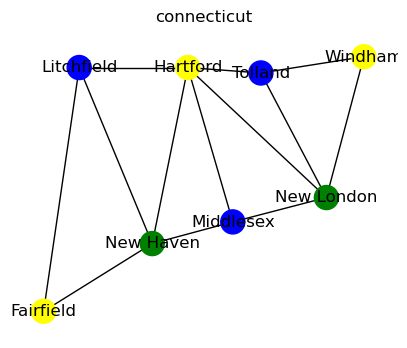

In [21]:
draw_map("connecticut", connecticut, (5,4), connecticut_colors)

<a id="three_ct"></a>
## Does the Four Color Theorem apply here?

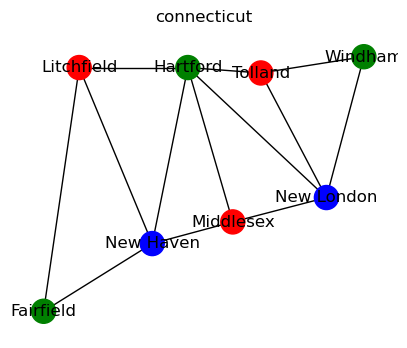

In [22]:
connecticut_colors = color_map( connecticut, ["red", "blue", "green"], trace=False)
if connecticut_colors:
    draw_map("connecticut", connecticut, (5,4), connecticut_colors)

## Problem 2. Color Europe Using Your solution

In [23]:
europe = {
    'coordinates': [(47, 28), (108, 14), (18, 147), (48, 83), (98, 59), (148, 57),
                 (160, 13), (63, 34), (84, 80), (82, 69), (136, 95), (194, 32),
                 (94, 97), (143, 149), (140, 111), (110, 67), (127, 40),
                 (118, 47), (111, 54), (189, 39), (202, 33), (82, 74),
                 (110, 162), (137, 102), (93, 55), (125, 32), (128, 37),
                 (122, 42), (116, 53), (124, 65), (146, 87), (138, 54),
                 (137, 41), (64, 90), (130, 22), (168, 29), (78, 55),
                 (116, 144), (122, 57), (158, 65), (122, 78), (112, 60),
                 (127, 48), (191, 118), (100, 78), (102, 35)],
 'edges': [(2, 3), (2, 33), (3, 33), (33, 36), (33, 21), (33, 8), (33, 22),
           (0, 7), (7, 36), (7, 45), (36, 21), (36, 9), (36, 44), (36, 24),
           (36, 45), (21, 8), (21, 9), (21, 44), (8, 44), (9, 44), (44, 12),
           (44, 37), (44, 40), (44, 15), (44, 41), (44, 24), (12, 22), (12, 37),
           (12, 40), (22, 37), (22, 13), (22, 43), (37, 13), (37, 14), (37, 23),
           (37, 40), (13, 14), (13, 43), (14, 23), (14, 43), (23, 10), (23, 30),
           (23, 43), (10, 40), (10, 30), (40, 15), (40, 29), (40, 30), (40, 39),
           (15, 41), (15, 29), (41, 4), (41, 24), (41, 45), (41, 18), (41, 38),
           (41, 29), (4, 24), (24, 45), (45, 1), (45, 34), (45, 25), (45, 27),
           (45, 17), (45, 28), (45, 18), (34, 25), (34, 26), (34, 32), (34, 6),
           (34, 35), (25, 26), (25, 16), (25, 27), (26, 16), (26, 42), (26, 32),
           (16, 27), (16, 42), (27, 17), (27, 42), (17, 42), (17, 28), (42, 28),
           (42, 38), (42, 31), (42, 32), (28, 18), (28, 38), (18, 38), (38, 29),
           (38, 39), (38, 31), (29, 39), (30, 39), (30, 43), (39, 5), (39, 31),
           (39, 43), (5, 31), (31, 32), (32, 35), (6, 35), (35, 19), (35, 11),
           (35, 20), (19, 11), (19, 20), (19, 43), (11, 20), (20, 43)],
 'nodes': ['Portugal', 'Malta', 'Iceland', 'Ireland', 'Liechtenstein',
           'Moldova', 'Cyprus', 'Spain', 'Netherlands', 'Luxembourg',
           'Lithuania', 'Armenia', 'Denmark', 'Finland', 'Estonia',
           'Czech Republic', 'Kosovo', 'Bosnia Herzegovina', 'Slovenia',
           'Georgia', 'Azerbaijan', 'Belgium', 'Norway', 'Latvia',
           'Switzerland', 'Albania', 'Macedonia', 'Montenegro', 'Croatia',
           'Slovakia', 'Belarus', 'Romania', 'Bulgaria', 'United Kingdom',
           'Greece', 'Turkey', 'France', 'Sweden', 'Hungary', 'Ukraine',
           'Poland', 'Austria', 'Serbia', 'Russia', 'Germany', 'Italy']}
print(europe)

{'coordinates': [(47, 28), (108, 14), (18, 147), (48, 83), (98, 59), (148, 57), (160, 13), (63, 34), (84, 80), (82, 69), (136, 95), (194, 32), (94, 97), (143, 149), (140, 111), (110, 67), (127, 40), (118, 47), (111, 54), (189, 39), (202, 33), (82, 74), (110, 162), (137, 102), (93, 55), (125, 32), (128, 37), (122, 42), (116, 53), (124, 65), (146, 87), (138, 54), (137, 41), (64, 90), (130, 22), (168, 29), (78, 55), (116, 144), (122, 57), (158, 65), (122, 78), (112, 60), (127, 48), (191, 118), (100, 78), (102, 35)], 'edges': [(2, 3), (2, 33), (3, 33), (33, 36), (33, 21), (33, 8), (33, 22), (0, 7), (7, 36), (7, 45), (36, 21), (36, 9), (36, 44), (36, 24), (36, 45), (21, 8), (21, 9), (21, 44), (8, 44), (9, 44), (44, 12), (44, 37), (44, 40), (44, 15), (44, 41), (44, 24), (12, 22), (12, 37), (12, 40), (22, 37), (22, 13), (22, 43), (37, 13), (37, 14), (37, 23), (37, 40), (13, 14), (13, 43), (14, 23), (14, 43), (23, 10), (23, 30), (23, 43), (10, 40), (10, 30), (40, 15), (40, 29), (40, 30), (40, 

Here we're testing to see if the adjacent nodes are colored differently:

In [24]:
europe_colors = color_map(europe, ["red", "blue", "green", "yellow"], trace=True)

Chosen Variable with Degree Heuristic: ('Italy', 11)
Value with Least Constraints: ('yellow', 11)
Chosen Variable with Degree Heuristic: ('Germany', 10)
Value with Least Constraints: ('yellow', 7)
Chosen Variable with Degree Heuristic: ('Serbia', 8)
Value with Least Constraints: ('yellow', 5)
Chosen Variable with Degree Heuristic: ('Russia', 8)
Value with Least Constraints: ('yellow', 8)
Chosen Variable with Degree Heuristic: ('Poland', 7)
Value with Least Constraints: ('green', 7)
Chosen Variable with Degree Heuristic: ('United Kingdom', 6)
Value with Least Constraints: ('yellow', 2)
Chosen Variable with Degree Heuristic: ('Turkey', 6)
Value with Least Constraints: ('yellow', 2)
Chosen Variable with Degree Heuristic: ('Hungary', 6)
Value with Least Constraints: ('green', 4)
Chosen Variable with Degree Heuristic: ('Sweden', 5)
Value with Least Constraints: ('blue', 5)
Chosen Variable with Degree Heuristic: ('Austria', 5)
Value with Least Constraints: ('blue', 5)
Chosen Variable with De

<a id="four_eu"></a>
#### Test Cases

In [25]:
edges = europe["edges"]
nodes = europe[ "nodes"]
colors = europe_colors
COLOR = 1

for start, end in edges:
    try:
        assert colors[start][COLOR] != colors[end][COLOR]
    except AssertionError:
        print(f"{nodes[start]} and {nodes[end]} are adjacent but have the same color.")

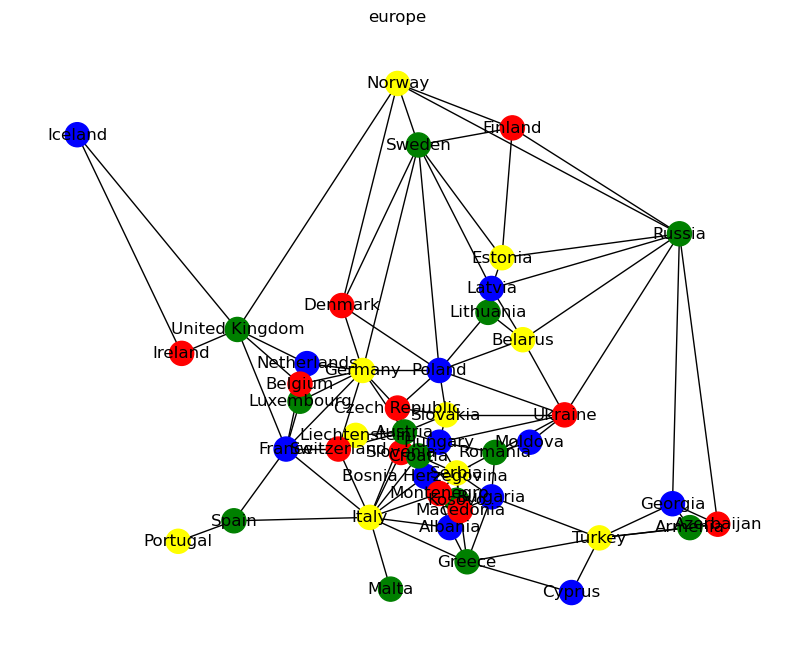

In [26]:
draw_map("europe", europe, (10,8), europe_colors)

<a id="three_eu"></a>
## Does the Four Color Theorem apply here?

In [27]:
europe_colors = color_map(europe, ["red", "blue", "green"], trace=False)
if europe_colors:
     draw_map("europe", europe, (10,8), europe_colors)
else: 
    print("No Solution Found")

No Solution Found


## Before You Submit...

1. Did you provide output exactly as requested?
2. Did you re-execute the entire notebook? ("Restart Kernel and Rull All Cells...")
3. If you did not complete the assignment or had difficulty please explain what gave you the most difficulty in the Markdown cell below.
4. Did you change the name of the file to `jhed_id.ipynb`?

Do not submit any other files.